In [1]:
import argparse
import os

import torch
import torch.utils.data

import model.transformer
import model.trainer as trainer
import utils.datasets
import utils.utils
import utils.plots as plots
import utils.counting as counting
import torchvision
import numpy as np
import warnings
from matplotlib import pyplot as plt

import utils.anchors
import cv2

import time
import pandas as pd

root = '/home/a01328525/'
#root = 'E:/Experiments/'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/a01328525/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/a01328525/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
def seed_everything(seed: int):
    import random, os
    import numpy as np
    import torch
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True


seed_everything(42)

In [3]:
model_runs = 1001
seed = np.random.randint(1000000)
seed_everything(seed)

import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['cbbox']#, 'cbbox']
folders_data = [root+'Datasets_STED/Zones_cbbox_dataset_01/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_masks_01/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_10/',#bboxes bgr
              #  root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 300

sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):

    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/explain_STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=48*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])

    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, 
                                            use_scheduler_dict=True, ReduceLROnPlateau=False, probAugment=1, 
                                            extract_masks=True, n_channels=3, saveEach=1)
    

Save results at /home/a01328525/Datasets_STED/runs_transformers/explain_STED_1001_nano_cbbox_bgr_diou_BitNet/
Weights normal init applied to model
The model has 367,914 trainable parameters
The model size: 1.474MB
Load train data with 3026 images
Load val data with 1377 images
Training for 300 epochs
 Ep:    0, Batches: 48,  Avg Loss Tr:  6.020,     Avg Time:  0.226s 
           Batches: 22,  Avg Loss Ev:  3.927,     Avg Time:  0.081s 
                                                                    Best saved at Epoch:    0
                                                                    Epoch:    0 finished in  1.044 minutes
 Ep:    1, Batches: 48,  Avg Loss Tr:  3.615,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  3.298,     Avg Time:  0.067s 
                                                                    Best saved at Epoch:    1
                                                                    Epoch:    1 finished in  2.044 minutes
 Ep:    2, Batches: 

           Batches: 22,  Avg Loss Ev:  1.146,     Avg Time:  0.068s 
                                                                     Epoch:   26 finished in 26.389 minutes
 Ep:   27, Batches: 48,  Avg Loss Tr:  1.168,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  1.103,     Avg Time:  0.068s 
                                                                    Best saved at Epoch:   27
                                                                    Epoch:   27 finished in 27.364 minutes
 Ep:   28, Batches: 48,  Avg Loss Tr:  1.152,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  1.122,     Avg Time:  0.068s 
                                                                     Epoch:   28 finished in 28.341 minutes
 Ep:   29, Batches: 48,  Avg Loss Tr:  1.159,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  1.177,     Avg Time:  0.068s 
                                                                     Epoch:   29 finished in 29.318 

 Ep:   56, Batches: 48,  Avg Loss Tr:  0.995,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  1.023,     Avg Time:  0.068s 
                                                                     Epoch:   56 finished in 56.033 minutes
 Ep:   57, Batches: 48,  Avg Loss Tr:  0.986,     Avg Time:  0.144s 
           Batches: 22,  Avg Loss Ev:  0.984,     Avg Time:  0.068s 
                                                                    Best saved at Epoch:   57
                                                                    Epoch:   57 finished in 57.097 minutes
 Ep:   58, Batches: 48,  Avg Loss Tr:  0.991,     Avg Time:  0.147s 
           Batches: 22,  Avg Loss Ev:  0.978,     Avg Time:  0.070s 
                                                                    Best saved at Epoch:   58
                                                                    Epoch:   58 finished in 58.139 minutes
 Ep:   59, Batches: 48,  Avg Loss Tr:  0.992,     Avg Time:  0.143s 
       

           Batches: 22,  Avg Loss Ev:  1.008,     Avg Time:  0.081s 
                                                                     Epoch:   88 finished in  1.360 hours
 Ep:   89, Batches: 48,  Avg Loss Tr:  0.925,     Avg Time:  0.172s 
           Batches: 22,  Avg Loss Ev:  1.022,     Avg Time:  0.070s 
                                                                     Epoch:   89 finished in  1.380 hours
 Ep:   90, Batches: 48,  Avg Loss Tr:  0.926,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.991,     Avg Time:  0.068s 
                                                                     Epoch:   90 finished in  1.396 hours
 Ep:   91, Batches: 48,  Avg Loss Tr:  0.908,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.945,     Avg Time:  0.068s 
                                                                    Best saved at Epoch:   91
                                                                    Epoch:   91 finished in  1.413 hours


 Ep:  121, Batches: 48,  Avg Loss Tr:  0.858,     Avg Time:  0.145s 
           Batches: 22,  Avg Loss Ev:  0.972,     Avg Time:  0.067s 
                                                                     Epoch:  121 finished in  1.908 hours
 Ep:  122, Batches: 48,  Avg Loss Tr:  0.861,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.948,     Avg Time:  0.067s 
                                                                     Epoch:  122 finished in  1.922 hours
 Ep:  123, Batches: 48,  Avg Loss Tr:  0.850,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  1.015,     Avg Time:  0.068s 
                                                                     Epoch:  123 finished in  1.934 hours
 Ep:  124, Batches: 48,  Avg Loss Tr:  0.858,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.938,     Avg Time:  0.067s 
                                                                     Epoch:  124 finished in  1.945 hours
 Ep:  125, Batches: 48, 

 Ep:  153, Batches: 48,  Avg Loss Tr:  0.842,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.925,     Avg Time:  0.068s 
                                                                     Epoch:  153 finished in  2.238 hours
 Ep:  154, Batches: 48,  Avg Loss Tr:  0.836,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.926,     Avg Time:  0.068s 
                                                                     Epoch:  154 finished in  2.247 hours
 Ep:  155, Batches: 48,  Avg Loss Tr:  0.849,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.951,     Avg Time:  0.068s 
                                                                     Epoch:  155 finished in  2.257 hours
 Ep:  156, Batches: 48,  Avg Loss Tr:  0.838,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.977,     Avg Time:  0.068s 
                                                                     Epoch:  156 finished in  2.266 hours
 Ep:  157, Batches: 48, 

 Ep:  186, Batches: 48,  Avg Loss Tr:  0.845,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.920,     Avg Time:  0.068s 
                                                                     Epoch:  186 finished in  2.554 hours
 Ep:  187, Batches: 48,  Avg Loss Tr:  0.840,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.962,     Avg Time:  0.068s 
                                                                     Epoch:  187 finished in  2.563 hours
 Ep:  188, Batches: 48,  Avg Loss Tr:  0.829,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.960,     Avg Time:  0.068s 
                                                                     Epoch:  188 finished in  2.573 hours
 Ep:  189, Batches: 48,  Avg Loss Tr:  0.829,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.936,     Avg Time:  0.068s 
                                                                     Epoch:  189 finished in  2.582 hours
 Ep:  190, Batches: 48, 

 Ep:  219, Batches: 48,  Avg Loss Tr:  0.819,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.946,     Avg Time:  0.068s 
                                                                     Epoch:  219 finished in  2.865 hours
 Ep:  220, Batches: 48,  Avg Loss Tr:  0.811,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.926,     Avg Time:  0.068s 
                                                                     Epoch:  220 finished in  2.875 hours
 Ep:  221, Batches: 48,  Avg Loss Tr:  0.808,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.912,     Avg Time:  0.068s 
                                                                     Epoch:  221 finished in  2.884 hours
 Ep:  222, Batches: 48,  Avg Loss Tr:  0.808,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.948,     Avg Time:  0.068s 
                                                                     Epoch:  222 finished in  2.894 hours
 Ep:  223, Batches: 48, 

 Ep:  252, Batches: 48,  Avg Loss Tr:  0.807,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.932,     Avg Time:  0.068s 
                                                                     Epoch:  252 finished in  3.179 hours
 Ep:  253, Batches: 48,  Avg Loss Tr:  0.809,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.922,     Avg Time:  0.067s 
                                                                     Epoch:  253 finished in  3.188 hours
 Ep:  254, Batches: 48,  Avg Loss Tr:  0.813,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.955,     Avg Time:  0.067s 
                                                                     Epoch:  254 finished in  3.198 hours
 Ep:  255, Batches: 48,  Avg Loss Tr:  0.813,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.914,     Avg Time:  0.067s 
                                                                     Epoch:  255 finished in  3.208 hours
 Ep:  256, Batches: 48, 

 Ep:  285, Batches: 48,  Avg Loss Tr:  0.804,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.932,     Avg Time:  0.068s 
                                                                     Epoch:  285 finished in  3.493 hours
 Ep:  286, Batches: 48,  Avg Loss Tr:  0.805,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.907,     Avg Time:  0.067s 
                                                                     Epoch:  286 finished in  3.503 hours
 Ep:  287, Batches: 48,  Avg Loss Tr:  0.810,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.926,     Avg Time:  0.067s 
                                                                     Epoch:  287 finished in  3.512 hours
 Ep:  288, Batches: 48,  Avg Loss Tr:  0.805,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  0.903,     Avg Time:  0.068s 
                                                                     Epoch:  288 finished in  3.521 hours
 Ep:  289, Batches: 48, 

In [4]:
model_runs = 1002
seed = np.random.randint(1000000)
seed_everything(seed)

import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['cbbox']#, 'cbbox']
folders_data = [root+'Datasets_STED/Zones_cbbox_dataset_01/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_masks_01/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_10/',#bboxes bgr
              #  root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 300

sub_name = 'nano'
augment = False

for obj, folder_data in zip(objs, folders_data):

    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/explain_STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=48*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])

    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, 
                                            use_scheduler_dict=True, ReduceLROnPlateau=False, probAugment=0, 
                                            extract_masks=True, n_channels=3, saveEach=1)

Save results at /home/a01328525/Datasets_STED/runs_transformers/explain_STED_1002_nano_cbbox_bgr_diou_BitNet/
Weights normal init applied to model
The model has 367,914 trainable parameters
The model size: 1.474MB
Load train data with 3026 images
Load val data with 1377 images
Training for 300 epochs
 Ep:    0, Batches: 48,  Avg Loss Tr:  8.584,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  3.845,     Avg Time:  0.068s 
                                                                    Best saved at Epoch:    0
                                                                    Epoch:    0 finished in  0.422 minutes
 Ep:    1, Batches: 48,  Avg Loss Tr:  3.370,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  3.569,     Avg Time:  0.068s 
                                                                    Best saved at Epoch:    1
                                                                    Epoch:    1 finished in  0.849 minutes
 Ep:    2, Batches: 

 Ep:   25, Batches: 48,  Avg Loss Tr:  1.160,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  1.138,     Avg Time:  0.068s 
                                                                    Best saved at Epoch:   25
                                                                    Epoch:   25 finished in 11.029 minutes
 Ep:   26, Batches: 48,  Avg Loss Tr:  1.131,     Avg Time:  0.142s 
           Batches: 22,  Avg Loss Ev:  1.161,     Avg Time:  0.068s 
                                                                     Epoch:   26 finished in 11.452 minutes
 Ep:   27, Batches: 48,  Avg Loss Tr:  1.110,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.102,     Avg Time:  0.068s 
                                                                    Best saved at Epoch:   27
                                                                    Epoch:   27 finished in 11.878 minutes
 Ep:   28, Batches: 48,  Avg Loss Tr:  1.090,     Avg Time:  0.143s 
       

           Batches: 22,  Avg Loss Ev:  0.983,     Avg Time:  0.068s 
                                                                    Best saved at Epoch:   55
                                                                    Epoch:   55 finished in 23.800 minutes
 Ep:   56, Batches: 48,  Avg Loss Tr:  0.926,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.059,     Avg Time:  0.068s 
                                                                     Epoch:   56 finished in 24.227 minutes
 Ep:   57, Batches: 48,  Avg Loss Tr:  0.925,     Avg Time:  0.144s 
           Batches: 22,  Avg Loss Ev:  1.104,     Avg Time:  0.068s 
                                                                     Epoch:   57 finished in 24.652 minutes
 Ep:   58, Batches: 48,  Avg Loss Tr:  0.924,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.010,     Avg Time:  0.068s 
                                                                     Epoch:   58 finished in 25.080 

           Batches: 22,  Avg Loss Ev:  1.036,     Avg Time:  0.068s 
                                                                     Epoch:   87 finished in 37.429 minutes
 Ep:   88, Batches: 48,  Avg Loss Tr:  0.842,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.996,     Avg Time:  0.068s 
                                                                     Epoch:   88 finished in 37.852 minutes
 Ep:   89, Batches: 48,  Avg Loss Tr:  0.836,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.064,     Avg Time:  0.068s 
                                                                     Epoch:   89 finished in 38.273 minutes
 Ep:   90, Batches: 48,  Avg Loss Tr:  0.818,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.064,     Avg Time:  0.068s 
                                                                     Epoch:   90 finished in 38.697 minutes
 Ep:   91, Batches: 48,  Avg Loss Tr:  0.826,     Avg Time:  0.143s 
           Batch

 Ep:  120, Batches: 48,  Avg Loss Tr:  0.754,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.020,     Avg Time:  0.068s 
                                                                     Epoch:  120 finished in 51.451 minutes
 Ep:  121, Batches: 48,  Avg Loss Tr:  0.750,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.982,     Avg Time:  0.068s 
                                                                     Epoch:  121 finished in 51.874 minutes
 Ep:  122, Batches: 48,  Avg Loss Tr:  0.755,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.196,     Avg Time:  0.068s 
                                                                     Epoch:  122 finished in 52.297 minutes
 Ep:  123, Batches: 48,  Avg Loss Tr:  0.750,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.979,     Avg Time:  0.068s 
                                                                     Epoch:  123 finished in 52.724 minutes
 Ep:  124, Batch

           Batches: 22,  Avg Loss Ev:  1.158,     Avg Time:  0.068s 
                                                                     Epoch:  153 finished in  1.091 hours
 Ep:  154, Batches: 48,  Avg Loss Tr:  0.719,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.114,     Avg Time:  0.068s 
                                                                     Epoch:  154 finished in  1.099 hours
 Ep:  155, Batches: 48,  Avg Loss Tr:  0.723,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.105,     Avg Time:  0.068s 
                                                                     Epoch:  155 finished in  1.106 hours
 Ep:  156, Batches: 48,  Avg Loss Tr:  0.719,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.096,     Avg Time:  0.068s 
                                                                     Epoch:  156 finished in  1.113 hours
 Ep:  157, Batches: 48,  Avg Loss Tr:  0.716,     Avg Time:  0.144s 
           Batches: 22, 

 Ep:  187, Batches: 48,  Avg Loss Tr:  0.697,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.024,     Avg Time:  0.068s 
                                                                     Epoch:  187 finished in  1.332 hours
 Ep:  188, Batches: 48,  Avg Loss Tr:  0.701,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.107,     Avg Time:  0.068s 
                                                                     Epoch:  188 finished in  1.339 hours
 Ep:  189, Batches: 48,  Avg Loss Tr:  0.699,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.019,     Avg Time:  0.068s 
                                                                     Epoch:  189 finished in  1.346 hours
 Ep:  190, Batches: 48,  Avg Loss Tr:  0.700,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  0.998,     Avg Time:  0.068s 
                                                                     Epoch:  190 finished in  1.353 hours
 Ep:  191, Batches: 48, 

 Ep:  221, Batches: 48,  Avg Loss Tr:  0.686,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.063,     Avg Time:  0.068s 
                                                                     Epoch:  221 finished in  1.573 hours
 Ep:  222, Batches: 48,  Avg Loss Tr:  0.687,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.177,     Avg Time:  0.068s 
                                                                     Epoch:  222 finished in  1.580 hours
 Ep:  223, Batches: 48,  Avg Loss Tr:  0.681,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.045,     Avg Time:  0.068s 
                                                                     Epoch:  223 finished in  1.587 hours
 Ep:  224, Batches: 48,  Avg Loss Tr:  0.683,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.037,     Avg Time:  0.068s 
                                                                     Epoch:  224 finished in  1.594 hours
 Ep:  225, Batches: 48, 

 Ep:  255, Batches: 48,  Avg Loss Tr:  0.675,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.007,     Avg Time:  0.068s 
                                                                     Epoch:  255 finished in  1.814 hours
 Ep:  256, Batches: 48,  Avg Loss Tr:  0.679,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.057,     Avg Time:  0.068s 
                                                                     Epoch:  256 finished in  1.821 hours
 Ep:  257, Batches: 48,  Avg Loss Tr:  0.682,     Avg Time:  0.144s 
           Batches: 22,  Avg Loss Ev:  1.065,     Avg Time:  0.068s 
                                                                     Epoch:  257 finished in  1.828 hours
 Ep:  258, Batches: 48,  Avg Loss Tr:  0.680,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.051,     Avg Time:  0.068s 
                                                                     Epoch:  258 finished in  1.835 hours
 Ep:  259, Batches: 48, 

 Ep:  289, Batches: 48,  Avg Loss Tr:  0.679,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.094,     Avg Time:  0.068s 
                                                                     Epoch:  289 finished in  2.054 hours
 Ep:  290, Batches: 48,  Avg Loss Tr:  0.677,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.054,     Avg Time:  0.068s 
                                                                     Epoch:  290 finished in  2.062 hours
 Ep:  291, Batches: 48,  Avg Loss Tr:  0.674,     Avg Time:  0.144s 
           Batches: 22,  Avg Loss Ev:  1.079,     Avg Time:  0.069s 
                                                                     Epoch:  291 finished in  2.069 hours
 Ep:  292, Batches: 48,  Avg Loss Tr:  0.677,     Avg Time:  0.143s 
           Batches: 22,  Avg Loss Ev:  1.067,     Avg Time:  0.068s 
                                                                     Epoch:  292 finished in  2.076 hours
 Ep:  293, Batches: 48, 

In [ ]:
import os
data_folder = folders_data[0]
file_names = os.listdir(data_folder+'train/images/')

image_path = data_folder + 'train/images/' + file_names[12] 
image_path

In [8]:
from tifffile import imread
image = imread(image_path)
image.shape

(224, 224, 10)

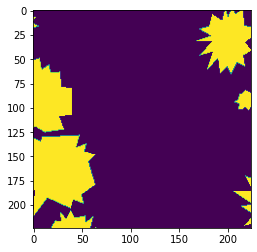

In [20]:
plt.imshow(image[...,8])

In [22]:
np.unique(image[...,8])

array([0., 1.], dtype=float32)

## Tiny VIT

In [4]:
model_runs = 10000#folder number to save results

for i in range(5):
    seed = np.random.randint(100000)
    seed_everything(seed)
    import model.trainer as trainer
    from dstadam import DSTAdam 

    img_size=224
    save_results=True
    n_model = 128
    num_blks = 1
    N_channels = 3
    ch_name = 'bgr'
    objs = ['cbbox']
    folders_data = [#root+'/Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                    root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
                   ]

    epochs = 200
    #model_runs = 10000 #folder number to save results
    augment = True

    for obj, folder_data in zip(objs, folders_data):

        import model.transformer    
        folder_save_results = root+"Datasets_STED/runs_transformers/TinyVIT_"+str(model_runs)+"_"+obj+"_"+ch_name+"_diou_notBitNet/"
        print("Save results at "+folder_save_results)
        model_runs+=1

        model = model.transformer.TinyViT_det(device=device, gamma=2.0, alpha=0.25).to(device)
        #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
        optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
        #print(optimizer.state_dict()['param_groups'][0]['lr'])

        #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

        model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                               device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                                ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/TinyVIT_10000_cbbox_bgr_diou_notBitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 1,083,664 trainable parameters
The model size: 27.873MB
Load train data with 3026 images
Load val data with 1822 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/TinyVIT_10001_cbbox_bgr_diou_notBitNet/
Weights normal init applied to model
The model has 1,083,664 trainable parameters
The model size: 27.873MB
Load train data with 3026 images
Load val data with 1822 images
Training for 200 epochs
 Ep:    0, Batches: 48,  Avg Loss Tr: 16.232,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.576,     Avg Time:  0.0

 Ep:   38, Batches: 48,  Avg Loss Tr:  1.149,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.462,     Avg Time:  0.018s 
 Ep:   39, Batches: 48,  Avg Loss Tr:  1.143,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.459,     Avg Time:  0.018s 
 Ep:   40, Batches: 48,  Avg Loss Tr:  1.138,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.439,     Avg Time:  0.019s 
                                                                     Epoch:   40 finished in 10.939 minutes
 Ep:   41, Batches: 48,  Avg Loss Tr:  1.126,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.431,     Avg Time:  0.018s 
 Ep:   42, Batches: 48,  Avg Loss Tr:  1.128,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.446,     Avg Time:  0.018s 
 Ep:   43, Batches: 48,  Avg Loss Tr:  1.118,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.449,     Avg Time:  0.018s 
 Ep:   44, Batches: 48,  Avg Loss Tr:  1.108,     Avg Time:  0.0

 Ep:  144, Batches: 48,  Avg Loss Tr:  1.014,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.477,     Avg Time:  0.018s 
 Ep:  145, Batches: 48,  Avg Loss Tr:  1.013,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.517,     Avg Time:  0.018s 
 Ep:  146, Batches: 48,  Avg Loss Tr:  1.005,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.420,     Avg Time:  0.018s 
 Ep:  147, Batches: 48,  Avg Loss Tr:  1.005,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.465,     Avg Time:  0.018s 
 Ep:  148, Batches: 48,  Avg Loss Tr:  1.014,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.465,     Avg Time:  0.019s 
 Ep:  149, Batches: 48,  Avg Loss Tr:  1.008,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.436,     Avg Time:  0.018s 
 Ep:  150, Batches: 48,  Avg Loss Tr:  1.006,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.419,     Avg Time:  0.018s 
                                  

           Batches: 29,  Avg Loss Ev:  1.520,     Avg Time:  0.019s 
 Ep:   39, Batches: 48,  Avg Loss Tr:  1.126,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.550,     Avg Time:  0.018s 
 Ep:   40, Batches: 48,  Avg Loss Tr:  1.124,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.488,     Avg Time:  0.019s 
                                                                     Epoch:   40 finished in 10.932 minutes
 Ep:   41, Batches: 48,  Avg Loss Tr:  1.115,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.506,     Avg Time:  0.018s 
 Ep:   42, Batches: 48,  Avg Loss Tr:  1.113,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.500,     Avg Time:  0.018s 
 Ep:   43, Batches: 48,  Avg Loss Tr:  1.111,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.522,     Avg Time:  0.018s 
 Ep:   44, Batches: 48,  Avg Loss Tr:  1.108,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.518,     Avg Time:  0.0

 Ep:  147, Batches: 48,  Avg Loss Tr:  1.013,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.517,     Avg Time:  0.019s 
 Ep:  148, Batches: 48,  Avg Loss Tr:  1.002,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.519,     Avg Time:  0.018s 
 Ep:  149, Batches: 48,  Avg Loss Tr:  1.003,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.500,     Avg Time:  0.019s 
 Ep:  150, Batches: 48,  Avg Loss Tr:  1.006,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.514,     Avg Time:  0.018s 
                                                                     Epoch:  150 finished in 40.127 minutes
 Ep:  151, Batches: 48,  Avg Loss Tr:  1.011,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.513,     Avg Time:  0.018s 
 Ep:  152, Batches: 48,  Avg Loss Tr:  1.005,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.512,     Avg Time:  0.019s 
 Ep:  153, Batches: 48,  Avg Loss Tr:  1.002,     Avg Time:  0.0

 Ep:    0, Batches: 48,  Avg Loss Tr:  9.352,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  3.122,     Avg Time:  0.019s 
                                                                    Best saved at Epoch:    0
                                                                    Epoch:    0 finished in  0.265 minutes
 Ep:    1, Batches: 48,  Avg Loss Tr:  2.208,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.457,     Avg Time:  0.019s 
                                                                    Best saved at Epoch:    1
 Ep:    2, Batches: 48,  Avg Loss Tr:  2.003,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.237,     Avg Time:  0.018s 
                                                                    Best saved at Epoch:    2
 Ep:    3, Batches: 48,  Avg Loss Tr:  1.864,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.089,     Avg Time:  0.018s 
                                                           

           Batches: 29,  Avg Loss Ev:  1.689,     Avg Time:  0.018s 
 Ep:  100, Batches: 48,  Avg Loss Tr:  1.074,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.720,     Avg Time:  0.018s 
                                                                     Epoch:  100 finished in 26.847 minutes
 Ep:  101, Batches: 48,  Avg Loss Tr:  1.071,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.700,     Avg Time:  0.019s 
 Ep:  102, Batches: 48,  Avg Loss Tr:  1.071,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.731,     Avg Time:  0.018s 
 Ep:  103, Batches: 48,  Avg Loss Tr:  1.069,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.734,     Avg Time:  0.018s 
 Ep:  104, Batches: 48,  Avg Loss Tr:  1.073,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.711,     Avg Time:  0.018s 
 Ep:  105, Batches: 48,  Avg Loss Tr:  1.070,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.699,     Avg Time:  0.0

 Ep:    5, Batches: 48,  Avg Loss Tr:  1.890,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.417,     Avg Time:  0.018s 
                                                                    Best saved at Epoch:    5
 Ep:    6, Batches: 48,  Avg Loss Tr:  1.821,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.141,     Avg Time:  0.018s 
                                                                    Best saved at Epoch:    6
 Ep:    7, Batches: 48,  Avg Loss Tr:  1.761,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.034,     Avg Time:  0.019s 
                                                                    Best saved at Epoch:    7
 Ep:    8, Batches: 48,  Avg Loss Tr:  1.697,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.092,     Avg Time:  0.019s 
 Ep:    9, Batches: 48,  Avg Loss Tr:  1.637,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.011,     Avg Time:  0.019s 
                            

 Ep:   51, Batches: 48,  Avg Loss Tr:  1.156,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.791,     Avg Time:  0.019s 
 Ep:   52, Batches: 48,  Avg Loss Tr:  1.151,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.780,     Avg Time:  0.019s 
 Ep:   53, Batches: 48,  Avg Loss Tr:  1.148,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.784,     Avg Time:  0.018s 
 Ep:   54, Batches: 48,  Avg Loss Tr:  1.140,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.781,     Avg Time:  0.018s 
 Ep:   55, Batches: 48,  Avg Loss Tr:  1.137,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.827,     Avg Time:  0.019s 
 Ep:   56, Batches: 48,  Avg Loss Tr:  1.135,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.810,     Avg Time:  0.018s 
 Ep:   57, Batches: 48,  Avg Loss Tr:  1.137,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.814,     Avg Time:  0.018s 
 Ep:   58, Batches: 48,  Avg Loss 

 Ep:  161, Batches: 48,  Avg Loss Tr:  1.086,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.811,     Avg Time:  0.018s 
 Ep:  162, Batches: 48,  Avg Loss Tr:  1.079,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.807,     Avg Time:  0.019s 
 Ep:  163, Batches: 48,  Avg Loss Tr:  1.082,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.869,     Avg Time:  0.019s 
 Ep:  164, Batches: 48,  Avg Loss Tr:  1.083,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.840,     Avg Time:  0.019s 
 Ep:  165, Batches: 48,  Avg Loss Tr:  1.086,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.837,     Avg Time:  0.018s 
 Ep:  166, Batches: 48,  Avg Loss Tr:  1.080,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.811,     Avg Time:  0.018s 
 Ep:  167, Batches: 48,  Avg Loss Tr:  1.074,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.820,     Avg Time:  0.018s 
 Ep:  168, Batches: 48,  Avg Loss 

In [2]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['cbbox']
folders_data = [#root+'/Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 200
model_runs = 201 #folder number to save results
sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/TinyVIT_"+str(model_runs)+"_"+obj+"_"+ch_name+"_diou_notBitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TinyViT_det(device=device, gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/TinyVIT_201_cbbox_bgr_diou_notBitNet/


/home/a01328525/transformer_object_dectection/TinyViT/models/tiny_vit.py:645: UserWarning: Overwriting tiny_vit_5m_224 in registry with TinyViT.models.tiny_vit.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def tiny_vit_5m_224(pretrained=False, **kwargs):
/home/a01328525/transformer_object_dectection/TinyViT/models/tiny_vit.py:658: UserWarning: Overwriting tiny_vit_11m_224 in registry with TinyViT.models.tiny_vit.tiny_vit_11m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def tiny_vit_11m_224(pretrained=False, **kwargs):
/home/a01328525/transformer_object_dectection/TinyViT/models/tiny_vit.py:671: UserWarning: Overwriting tiny_vit_21m_224 in registry with TinyViT.models.tiny_vit.tiny_vit_21m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def tiny_vit_21m_224(

Weights normal init applied to model
The model has 1,083,664 trainable parameters
The model size: 27.873MB
Load train data with 3026 images
Load val data with 1822 images
Training for 200 epochs


/home/a01328525/anaconda3/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


 Ep:    0, Batches: 48,  Avg Loss Tr: 15.066,     Avg Time:  0.107s 
           Batches: 29,  Avg Loss Ev:  2.767,     Avg Time:  0.022s 
                                                                    Best saved at Epoch:    0
                                                                    Epoch:    0 finished in  0.330 minutes
 Ep:    1, Batches: 48,  Avg Loss Tr:  2.375,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.597,     Avg Time:  0.020s 
                                                                    Best saved at Epoch:    1
 Ep:    2, Batches: 48,  Avg Loss Tr:  2.116,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.524,     Avg Time:  0.019s 
                                                                    Best saved at Epoch:    2
 Ep:    3, Batches: 48,  Avg Loss Tr:  2.016,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  2.069,     Avg Time:  0.020s 
                                                           

 Ep:   42, Batches: 48,  Avg Loss Tr:  1.186,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.688,     Avg Time:  0.020s 
 Ep:   43, Batches: 48,  Avg Loss Tr:  1.177,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.624,     Avg Time:  0.020s 
 Ep:   44, Batches: 48,  Avg Loss Tr:  1.164,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.648,     Avg Time:  0.020s 
 Ep:   45, Batches: 48,  Avg Loss Tr:  1.164,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.606,     Avg Time:  0.020s 
 Ep:   46, Batches: 48,  Avg Loss Tr:  1.163,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.688,     Avg Time:  0.020s 
 Ep:   47, Batches: 48,  Avg Loss Tr:  1.157,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.623,     Avg Time:  0.020s 
 Ep:   48, Batches: 48,  Avg Loss Tr:  1.153,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.625,     Avg Time:  0.018s 
 Ep:   49, Batches: 48,  Avg Loss 

 Ep:  151, Batches: 48,  Avg Loss Tr:  1.064,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.661,     Avg Time:  0.020s 
 Ep:  152, Batches: 48,  Avg Loss Tr:  1.066,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.629,     Avg Time:  0.020s 
 Ep:  153, Batches: 48,  Avg Loss Tr:  1.062,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.619,     Avg Time:  0.019s 
 Ep:  154, Batches: 48,  Avg Loss Tr:  1.065,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.616,     Avg Time:  0.020s 
 Ep:  155, Batches: 48,  Avg Loss Tr:  1.059,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.614,     Avg Time:  0.020s 
 Ep:  156, Batches: 48,  Avg Loss Tr:  1.056,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.625,     Avg Time:  0.020s 
 Ep:  157, Batches: 48,  Avg Loss Tr:  1.063,     Avg Time:  0.076s 
           Batches: 29,  Avg Loss Ev:  1.612,     Avg Time:  0.020s 
 Ep:  158, Batches: 48,  Avg Loss 

# PVT2

In [6]:
model_runs = 10000#folder number to save results

for i in range(5):
    seed = np.random.randint(100000)
    seed_everything(seed)
    import model.trainer as trainer
    from dstadam import DSTAdam 

    img_size=224
    save_results=True
    n_model = 128
    num_blks = 1
    N_channels = 3
    ch_name = 'bgr'
    objs = ['cbbox']
    folders_data = [#root+'/Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                    root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
                   ]

    epochs = 200
    #model_runs = 10000 #folder number to save results
    augment = True

    for obj, folder_data in zip(objs, folders_data):

        import model.transformer    
        folder_save_results = root+"Datasets_STED/runs_transformers/PVT2_"+str(model_runs)+"_"+obj+"_"+ch_name+"_diou_notBitNet/"
        print("Save results at "+folder_save_results)
        model_runs+=1

        model = model.transformer.PVT_det(device=device, gamma=2.0, alpha=0.25).to(device)
        #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
        optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
        #print(optimizer.state_dict()['param_groups'][0]['lr'])

        #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

        model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                               device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                                ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/PVT2_10000_cbbox_bgr_diou_notBitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 937,808 trainable parameters
The model size: 17.395MB
Load train data with 3026 images
Load val data with 1822 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/PVT2_10001_cbbox_bgr_diou_notBitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 937,808 trainable parameters
The model size: 17.395MB
Load train data with 3026 images
Load val data with 182

 Ep:   89, Batches: 48,  Avg Loss Tr:  1.347,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.466,     Avg Time:  0.015s 
 Ep:   90, Batches: 48,  Avg Loss Tr:  1.352,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.446,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   90
                                                                    Epoch:   90 finished in 19.989 minutes
 Ep:   91, Batches: 48,  Avg Loss Tr:  1.347,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.481,     Avg Time:  0.015s 
 Ep:   92, Batches: 48,  Avg Loss Tr:  1.348,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.470,     Avg Time:  0.015s 
 Ep:   93, Batches: 48,  Avg Loss Tr:  1.348,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.464,     Avg Time:  0.016s 
 Ep:   94, Batches: 48,  Avg Loss Tr:  1.360,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1

 Ep:  141, Batches: 48,  Avg Loss Tr:  1.321,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.437,     Avg Time:  0.015s 
 Ep:  142, Batches: 48,  Avg Loss Tr:  1.322,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.473,     Avg Time:  0.015s 
 Ep:  143, Batches: 48,  Avg Loss Tr:  1.322,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.454,     Avg Time:  0.015s 
 Ep:  144, Batches: 48,  Avg Loss Tr:  1.319,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.416,     Avg Time:  0.015s 
 Ep:  145, Batches: 48,  Avg Loss Tr:  1.315,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.462,     Avg Time:  0.015s 
 Ep:  146, Batches: 48,  Avg Loss Tr:  1.320,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.519,     Avg Time:  0.015s 
 Ep:  147, Batches: 48,  Avg Loss Tr:  1.320,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.431,     Avg Time:  0.015s 
 Ep:  148, Batches: 48,  Avg Loss 

 Ep:   37, Batches: 48,  Avg Loss Tr:  1.456,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.571,     Avg Time:  0.016s 
 Ep:   38, Batches: 48,  Avg Loss Tr:  1.457,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.534,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   38
 Ep:   39, Batches: 48,  Avg Loss Tr:  1.448,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.574,     Avg Time:  0.015s 
 Ep:   40, Batches: 48,  Avg Loss Tr:  1.446,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.635,     Avg Time:  0.016s 
                                                                     Epoch:   40 finished in  9.023 minutes
 Ep:   41, Batches: 48,  Avg Loss Tr:  1.444,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.537,     Avg Time:  0.015s 
 Ep:   42, Batches: 48,  Avg Loss Tr:  1.450,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  

 Ep:  140, Batches: 48,  Avg Loss Tr:  1.253,     Avg Time:  0.037s 
           Batches: 29,  Avg Loss Ev:  1.513,     Avg Time:  0.015s 
                                                                     Epoch:  140 finished in 31.016 minutes
 Ep:  141, Batches: 48,  Avg Loss Tr:  1.254,     Avg Time:  0.037s 
           Batches: 29,  Avg Loss Ev:  1.443,     Avg Time:  0.015s 
 Ep:  142, Batches: 48,  Avg Loss Tr:  1.253,     Avg Time:  0.037s 
           Batches: 29,  Avg Loss Ev:  1.405,     Avg Time:  0.016s 
 Ep:  143, Batches: 48,  Avg Loss Tr:  1.254,     Avg Time:  0.037s 
           Batches: 29,  Avg Loss Ev:  1.428,     Avg Time:  0.016s 
 Ep:  144, Batches: 48,  Avg Loss Tr:  1.250,     Avg Time:  0.037s 
           Batches: 29,  Avg Loss Ev:  1.468,     Avg Time:  0.015s 
 Ep:  145, Batches: 48,  Avg Loss Tr:  1.251,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.494,     Avg Time:  0.015s 
 Ep:  146, Batches: 48,  Avg Loss Tr:  1.250,     Avg Time:  0.0

 Ep:   36, Batches: 48,  Avg Loss Tr:  1.436,     Avg Time:  0.036s  
           Batches: 29,  Avg Loss Ev:  1.560,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   36
 Ep:   37, Batches: 48,  Avg Loss Tr:  1.438,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.581,     Avg Time:  0.016s 
 Ep:   38, Batches: 48,  Avg Loss Tr:  1.418,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.552,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   38
 Ep:   39, Batches: 48,  Avg Loss Tr:  1.412,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.521,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   39
 Ep:   40, Batches: 48,  Avg Loss Tr:  1.426,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.567,     Avg Time:  0.015s 
                           

 Ep:   86, Batches: 48,  Avg Loss Tr:  1.247,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.424,     Avg Time:  0.015s 
 Ep:   87, Batches: 48,  Avg Loss Tr:  1.253,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.417,     Avg Time:  0.015s 
 Ep:   88, Batches: 48,  Avg Loss Tr:  1.249,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.469,     Avg Time:  0.015s 
 Ep:   89, Batches: 48,  Avg Loss Tr:  1.251,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.448,     Avg Time:  0.015s 
 Ep:   90, Batches: 48,  Avg Loss Tr:  1.246,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.427,     Avg Time:  0.016s 
                                                                     Epoch:   90 finished in 19.994 minutes
 Ep:   91, Batches: 48,  Avg Loss Tr:  1.242,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.457,     Avg Time:  0.016s 
 Ep:   92, Batches: 48,  Avg Loss Tr:  1.245,     Avg Time:  0.0

 Ep:  141, Batches: 48,  Avg Loss Tr:  1.212,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.385,     Avg Time:  0.016s 
                                                                    Best saved at Epoch:  141
 Ep:  142, Batches: 48,  Avg Loss Tr:  1.211,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.424,     Avg Time:  0.016s 
 Ep:  143, Batches: 48,  Avg Loss Tr:  1.205,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.464,     Avg Time:  0.015s 
 Ep:  144, Batches: 48,  Avg Loss Tr:  1.207,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.462,     Avg Time:  0.015s 
 Ep:  145, Batches: 48,  Avg Loss Tr:  1.206,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.479,     Avg Time:  0.016s 
 Ep:  146, Batches: 48,  Avg Loss Tr:  1.208,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.456,     Avg Time:  0.016s 
 Ep:  147, Batches: 48,  Avg Loss Tr:  1.206,     Avg Time:  0.036s 
         

 Ep:   37, Batches: 48,  Avg Loss Tr:  1.456,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.562,     Avg Time:  0.015s 
 Ep:   38, Batches: 48,  Avg Loss Tr:  1.453,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.541,     Avg Time:  0.015s 
 Ep:   39, Batches: 48,  Avg Loss Tr:  1.440,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.582,     Avg Time:  0.015s 
 Ep:   40, Batches: 48,  Avg Loss Tr:  1.431,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.556,     Avg Time:  0.016s 
                                                                     Epoch:   40 finished in  9.000 minutes
 Ep:   41, Batches: 48,  Avg Loss Tr:  1.437,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.522,     Avg Time:  0.016s 
                                                                    Best saved at Epoch:   41
 Ep:   42, Batches: 48,  Avg Loss Tr:  1.430,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  

           Batches: 29,  Avg Loss Ev:  1.476,     Avg Time:  0.016s 
 Ep:  140, Batches: 48,  Avg Loss Tr:  1.240,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.448,     Avg Time:  0.015s 
                                                                     Epoch:  140 finished in 30.888 minutes
 Ep:  141, Batches: 48,  Avg Loss Tr:  1.233,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.521,     Avg Time:  0.015s 
 Ep:  142, Batches: 48,  Avg Loss Tr:  1.238,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.579,     Avg Time:  0.015s 
 Ep:  143, Batches: 48,  Avg Loss Tr:  1.238,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.467,     Avg Time:  0.015s 
 Ep:  144, Batches: 48,  Avg Loss Tr:  1.241,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.430,     Avg Time:  0.016s 
 Ep:  145, Batches: 48,  Avg Loss Tr:  1.238,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.460,     Avg Time:  0.0

In [3]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['cbbox']
folders_data = [#root+'/Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 200
model_runs = 202 #folder number to save results
sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/PVT2_"+str(model_runs)+"_"+obj+"_"+ch_name+"_diou_notBitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.PVT_det(device=device, gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/PVT2_202_cbbox_bgr_diou_notBitNet/
Weights normal init applied to model
The model has 937,808 trainable parameters
The model size: 17.395MB
Load train data with 3026 images
Load val data with 1822 images
Training for 200 epochs
 Ep:    0, Batches: 48,  Avg Loss Tr:  9.071,     Avg Time:  0.038s 
           Batches: 29,  Avg Loss Ev:  3.613,     Avg Time:  0.017s 
                                                                    Best saved at Epoch:    0
                                                                    Epoch:    0 finished in  0.239 minutes
 Ep:    1, Batches: 48,  Avg Loss Tr:  2.740,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  2.365,     Avg Time:  0.017s 
                                                                    Best saved at Epoch:    1
 Ep:    2, Batches: 48,  Avg Loss Tr:  2.262,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  2.209,     Avg Time:  0.016s 

 Ep:   41, Batches: 48,  Avg Loss Tr:  1.445,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.579,     Avg Time:  0.017s 
 Ep:   42, Batches: 48,  Avg Loss Tr:  1.443,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.586,     Avg Time:  0.017s 
 Ep:   43, Batches: 48,  Avg Loss Tr:  1.427,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.605,     Avg Time:  0.017s 
 Ep:   44, Batches: 48,  Avg Loss Tr:  1.432,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.558,     Avg Time:  0.017s 
                                                                    Best saved at Epoch:   44
 Ep:   45, Batches: 48,  Avg Loss Tr:  1.428,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.639,     Avg Time:  0.017s 
 Ep:   46, Batches: 48,  Avg Loss Tr:  1.421,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.588,     Avg Time:  0.017s 
 Ep:   47, Batches: 48,  Avg Loss Tr:  1.416,     Avg Time:  0.036s 
         

 Ep:  145, Batches: 48,  Avg Loss Tr:  1.321,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.546,     Avg Time:  0.017s 
 Ep:  146, Batches: 48,  Avg Loss Tr:  1.317,     Avg Time:  0.037s 
           Batches: 29,  Avg Loss Ev:  1.610,     Avg Time:  0.017s 
 Ep:  147, Batches: 48,  Avg Loss Tr:  1.316,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.582,     Avg Time:  0.017s 
 Ep:  148, Batches: 48,  Avg Loss Tr:  1.319,     Avg Time:  0.036s 
           Batches: 29,  Avg Loss Ev:  1.473,     Avg Time:  0.017s 
 Ep:  149, Batches: 48,  Avg Loss Tr:  1.316,     Avg Time:  0.038s 
           Batches: 29,  Avg Loss Ev:  1.530,     Avg Time:  0.017s 
 Ep:  150, Batches: 48,  Avg Loss Tr:  1.318,     Avg Time:  0.037s 
           Batches: 29,  Avg Loss Ev:  1.536,     Avg Time:  0.017s 
                                                                     Epoch:  150 finished in 35.795 minutes
 Ep:  151, Batches: 48,  Avg Loss Tr:  1.316,     Avg Time:  0.0

# Train nano models

In [4]:
model_runs = 10000#folder number to save results

seed = np.random.randint(100000)
seed_everything(seed)

import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=False
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['cbbox']#, 'cbbox']
folders_data = [root+'Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_masks_01/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_10/',#bboxes bgr
              #  root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 200

sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):

    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.01)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])

    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=1, use_optimizer_dict=True, 
                                            use_scheduler_dict=True, ReduceLROnPlateau=False, probAugment=0.5, 
                                            extract_masks=True, n_channels=3)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_10000_nano_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,576 trainable parameters
The model size: 1.400MB
Load train data with 3026 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes


In [4]:
model_runs = 2#folder number to save results

seed = np.random.randint(100000)
seed_everything(seed)

import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['cbbox']#, 'cbbox']
folders_data = [root+'Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_masks_01/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_10/',#bboxes bgr
              #  root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 10000

sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):

    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.01)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])

    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, 
                                            use_scheduler_dict=True, ReduceLROnPlateau=False, probAugment=0.5, 
                                            extract_masks=True, n_channels=3)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_2_nano_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 446,860 trainable parameters
The model size: 1.790MB
Load train data with 3026 images
Load val data with 1377 images
Training for 39 epochs
 Ep:  161, Batches: 48,  Avg Loss Tr:  0.758,     Avg Time:  0.138s 
           Batches: 22,  Avg Loss Ev:  0.863,     Avg Time:  0.044s 
 Ep:  162, Batches: 48,  Avg Loss Tr:  0.755,     Avg Time:  0.070s 
           Batches: 22,  Avg Loss Ev:  0.874,     Avg Time:  0.036s 
 Ep:  163, Batches: 48,  Avg Loss Tr:  0.754,     Avg Time:  0.069s 
           Batches: 22,  Avg Loss Ev:  0.863,     Avg Time:  0.036s 
 Ep:  164, Batches: 48,  Avg Loss Tr:  0.753,     Avg Time:  0.069s 
           Batches: 22,  Avg Loss Ev:  0.870,     A

In [4]:
model_runs = 10000#folder number to save results

for i in range(5):
    seed = np.random.randint(100000)
    seed_everything(seed)
    
    import model.trainer as trainer
    from dstadam import DSTAdam 

    img_size=224
    save_results=True
    n_model = 128
    num_blks = 1
    N_channels = 3
    ch_name = 'bgr'
    objs = ['cbbox']#, 'cbbox']
    folders_data = [#root+'Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                    #root+'Datasets_YOLO/Zones_cbbox_dataset_masks_01/',#bboxes bgr
                    root+'Datasets_YOLO/Zones_cbbox_dataset_10/',#bboxes bgr
                  #  root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
                   ]

    epochs = 200
    
    sub_name = 'nano'
    augment = True

    for obj, folder_data in zip(objs, folders_data):

        import model.transformer    
        folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
        print("Save results at "+folder_save_results)
        model_runs+=1

        model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                             obj = obj, device=device, bitNet=True,
                                                            gamma=2.0, alpha=0.25, segment=False).to(device)
        #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
        optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.01)
        #print(optimizer.state_dict()['param_groups'][0]['lr'])

        #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

        model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                               device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                                ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_10000_nano_cbbox_bgr_diou_BitNet/
Weights normal init applied to model
The model has 349,576 trainable parameters
The model size: 1.400MB
Load train data with 3026 images
Load val data with 1822 images
Training for 200 epochs
 Ep:    0, Batches: 48,  Avg Loss Tr: 18.814,     Avg Time:  0.103s 
           Batches: 29,  Avg Loss Ev:  9.613,     Avg Time:  0.019s 
                                                                    Best saved at Epoch:    0
                                                                    Epoch:    0 finished in  0.643 minutes
 Ep:    1, Batches: 48,  Avg Loss Tr:  6.698,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  3.854,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:    1
 Ep:    2, Batches: 48,  Avg Loss Tr:  2.852,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  2.078,     Avg Time:  0.01

           Batches: 29,  Avg Loss Ev:  0.754,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   98
 Ep:   99, Batches: 48,  Avg Loss Tr:  0.724,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.798,     Avg Time:  0.015s 
 Ep:  100, Batches: 48,  Avg Loss Tr:  0.722,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.783,     Avg Time:  0.015s 
                                                                     Epoch:  100 finished in 24.784 minutes
 Ep:  101, Batches: 48,  Avg Loss Tr:  0.711,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.748,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:  101
 Ep:  102, Batches: 48,  Avg Loss Tr:  0.708,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.762,     Avg Time:  0.015s 
 Ep:  103, Batches: 48,  Avg Loss Tr:  0.708,     Avg Time:  0.040s 
           Bat

 Ep:  151, Batches: 48,  Avg Loss Tr:  0.701,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.740,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:  151
 Ep:  152, Batches: 48,  Avg Loss Tr:  0.701,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.752,     Avg Time:  0.015s 
 Ep:  153, Batches: 48,  Avg Loss Tr:  0.705,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.747,     Avg Time:  0.015s 
 Ep:  154, Batches: 48,  Avg Loss Tr:  0.698,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.754,     Avg Time:  0.015s 
 Ep:  155, Batches: 48,  Avg Loss Tr:  0.701,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.746,     Avg Time:  0.015s 
 Ep:  156, Batches: 48,  Avg Loss Tr:  0.701,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.740,     Avg Time:  0.015s 
                                                                    Best saved

 Ep:    1, Batches: 48,  Avg Loss Tr:  2.936,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  2.133,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:    1
 Ep:    2, Batches: 48,  Avg Loss Tr:  1.746,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  1.595,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:    2
 Ep:    3, Batches: 48,  Avg Loss Tr:  1.454,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  1.420,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:    3
 Ep:    4, Batches: 48,  Avg Loss Tr:  1.329,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  1.297,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:    4
 Ep:    5, Batches: 48,  Avg Loss Tr:  1.239,     Avg Time:  0.040s 
   

 Ep:   92, Batches: 48,  Avg Loss Tr:  0.715,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.765,     Avg Time:  0.015s 
 Ep:   93, Batches: 48,  Avg Loss Tr:  0.716,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.767,     Avg Time:  0.015s 
 Ep:   94, Batches: 48,  Avg Loss Tr:  0.714,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.781,     Avg Time:  0.015s 
 Ep:   95, Batches: 48,  Avg Loss Tr:  0.715,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.760,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   95
 Ep:   96, Batches: 48,  Avg Loss Tr:  0.717,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.772,     Avg Time:  0.015s 
 Ep:   97, Batches: 48,  Avg Loss Tr:  0.715,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.804,     Avg Time:  0.015s 
 Ep:   98, Batches: 48,  Avg Loss Tr:  0.713,     Avg Time:  0.040s 
         

...

 Ep:  141, Batches: 48,  Avg Loss Tr:  0.702,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.776,     Avg Time:  0.016s 
 Ep:  142, Batches: 48,  Avg Loss Tr:  0.707,     Avg Time:  0.043s 
           Batches: 29,  Avg Loss Ev:  0.755,     Avg Time:  0.017s 
 Ep:  143, Batches: 48,  Avg Loss Tr:  0.699,     Avg Time:  0.047s 
           Batches: 29,  Avg Loss Ev:  0.751,     Avg Time:  0.016s 
 Ep:  144, Batches: 48,  Avg Loss Tr:  0.702,     Avg Time:  0.046s 
           Batches: 29,  Avg Loss Ev:  0.753,     Avg Time:  0.016s 
 Ep:  145, Batches: 48,  Avg Loss Tr:  0.701,     Avg Time:  0.047s 
           Batches: 29,  Avg Loss Ev:  0.746,     Avg Time:  0.016s 
 Ep:  146, Batches: 48,  Avg Loss Tr:  0.699,     Avg Time:  0.047s 
           Batches: 29,  Avg Loss Ev:  0.763,     Avg Time:  0.015s 
 Ep:  147, Batches: 48,  Avg Loss Tr:  0.701,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.754,     Avg Time:  0.015s 
 Ep:  148, Batches: 48,  Avg Loss 

 Ep:   35, Batches: 48,  Avg Loss Tr:  0.837,     Avg Time:  0.047s 
           Batches: 29,  Avg Loss Ev:  0.877,     Avg Time:  0.017s 
 Ep:   36, Batches: 48,  Avg Loss Tr:  0.819,     Avg Time:  0.047s 
           Batches: 29,  Avg Loss Ev:  0.842,     Avg Time:  0.017s 
 Ep:   37, Batches: 48,  Avg Loss Tr:  0.818,     Avg Time:  0.048s 
           Batches: 29,  Avg Loss Ev:  0.862,     Avg Time:  0.015s 
 Ep:   38, Batches: 48,  Avg Loss Tr:  0.830,     Avg Time:  0.048s 
           Batches: 29,  Avg Loss Ev:  0.905,     Avg Time:  0.015s 
 Ep:   39, Batches: 48,  Avg Loss Tr:  0.811,     Avg Time:  0.048s 
           Batches: 29,  Avg Loss Ev:  0.837,     Avg Time:  0.016s 
                                                                    Best saved at Epoch:   39
 Ep:   40, Batches: 48,  Avg Loss Tr:  0.802,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.868,     Avg Time:  0.015s 
                                                                     Epoch:   

 Ep:  136, Batches: 48,  Avg Loss Tr:  0.714,     Avg Time:  0.046s 
           Batches: 29,  Avg Loss Ev:  0.784,     Avg Time:  0.018s 
 Ep:  137, Batches: 48,  Avg Loss Tr:  0.712,     Avg Time:  0.048s 
           Batches: 29,  Avg Loss Ev:  0.753,     Avg Time:  0.017s 
                                                                    Best saved at Epoch:  137
 Ep:  138, Batches: 48,  Avg Loss Tr:  0.717,     Avg Time:  0.048s 
           Batches: 29,  Avg Loss Ev:  0.772,     Avg Time:  0.017s 
 Ep:  139, Batches: 48,  Avg Loss Tr:  0.713,     Avg Time:  0.047s 
           Batches: 29,  Avg Loss Ev:  0.803,     Avg Time:  0.017s 
 Ep:  140, Batches: 48,  Avg Loss Tr:  0.719,     Avg Time:  0.048s 
           Batches: 29,  Avg Loss Ev:  0.775,     Avg Time:  0.018s 
                                                                     Epoch:  140 finished in 37.601 minutes
 Ep:  141, Batches: 48,  Avg Loss Tr:  0.713,     Avg Time:  0.048s 
           Batches: 29,  Avg Loss Ev:  

 Ep:   31, Batches: 48,  Avg Loss Tr:  0.896,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.946,     Avg Time:  0.015s 
 Ep:   32, Batches: 48,  Avg Loss Tr:  0.853,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.923,     Avg Time:  0.015s 
 Ep:   33, Batches: 48,  Avg Loss Tr:  0.822,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.843,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   33
 Ep:   34, Batches: 48,  Avg Loss Tr:  0.811,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.858,     Avg Time:  0.015s 
 Ep:   35, Batches: 48,  Avg Loss Tr:  0.805,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.839,     Avg Time:  0.015s 
                                                                    Best saved at Epoch:   35
 Ep:   36, Batches: 48,  Avg Loss Tr:  0.799,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.812,     Avg

           Batches: 29,  Avg Loss Ev:  0.761,     Avg Time:  0.016s 
 Ep:  132, Batches: 48,  Avg Loss Tr:  0.702,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.769,     Avg Time:  0.015s 
 Ep:  133, Batches: 48,  Avg Loss Tr:  0.699,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.759,     Avg Time:  0.016s 
 Ep:  134, Batches: 48,  Avg Loss Tr:  0.705,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.760,     Avg Time:  0.016s 
 Ep:  135, Batches: 48,  Avg Loss Tr:  0.702,     Avg Time:  0.041s 
           Batches: 29,  Avg Loss Ev:  0.798,     Avg Time:  0.016s 
 Ep:  136, Batches: 48,  Avg Loss Tr:  0.704,     Avg Time:  0.041s 
           Batches: 29,  Avg Loss Ev:  0.770,     Avg Time:  0.015s 
 Ep:  137, Batches: 48,  Avg Loss Tr:  0.699,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss Ev:  0.752,     Avg Time:  0.015s 
 Ep:  138, Batches: 48,  Avg Loss Tr:  0.704,     Avg Time:  0.040s 
           Batches: 29,  Avg Loss 

In [2]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['cbbox']#, 'cbbox']
folders_data = [#root+'Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                #root+'Datasets_YOLO/Zones_cbbox_dataset_masks_01/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/',#bboxes bgr
              #  root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 200
model_runs = 208#folder number to save results
sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25, segment=False).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.01)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_208_nano_cbbox_bgr_diou_BitNet/
Weights normal init applied to model
The model has 349,576 trainable parameters
The model size: 1.400MB
Load train data with 3026 images
Load val data with 1822 images
Training for 200 epochs
 Ep:    0, Batches: 48,  Avg Loss Tr: 11.365,     Avg Time:  0.070s 
           Batches: 29,  Avg Loss Ev:  5.639,     Avg Time:  0.019s 
                                                                    Best saved at Epoch:    0
                                                                    Epoch:    0 finished in  0.464 minutes
 Ep:    1, Batches: 48,  Avg Loss Tr:  3.857,     Avg Time:  0.042s 
           Batches: 29,  Avg Loss Ev:  2.982,     Avg Time:  0.017s 
                                                                    Best saved at Epoch:    1
 Ep:    2, Batches: 48,  Avg Loss Tr:  2.663,     Avg Time:  0.043s 
           Batches: 29,  Avg Loss Ev:  2.433,     Avg Time:  0.017s

KeyboardInterrupt: 

In [5]:
import model.trainer as trainer

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 5
ch_name = 'multispectral'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_11/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_11/'#cbboxes bgr
               ]

epochs = 200
model_runs = 102 #folder number to save results
sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_102_nano_bbox_multispectral_diou_BitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 358,058 trainable parameters
The model size: 1.434MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_103_nano_cbbox_multispectral_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 358

# Train small models

In [3]:
#####################################################
# RUN STATS small

model_runs = 10000#folder number to save results

for i in range(5):
    seed = np.random.randint(100000)
    seed_everything(seed)
    
    import model.trainer as trainer
    from dstadam import DSTAdam 

    img_size=224
    save_results=True
    n_model = 256
    num_blks = 1
    N_channels = 3
    ch_name = 'bgr'
    objs = ['cbbox']#, 'cbbox']
    folders_data = [#root+'Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                    #root+'Datasets_YOLO/Zones_cbbox_dataset_masks_01/',#bboxes bgr
                    root+'Datasets_YOLO/Zones_cbbox_dataset_10/',#bboxes bgr
                  #  root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
                   ]

    epochs = 200
    
    sub_name = 'small'
    augment = True

    for obj, folder_data in zip(objs, folders_data):

        import model.transformer    
        folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
        print("Save results at "+folder_save_results)
        model_runs+=1

        model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                             obj = obj, device=device, bitNet=True,
                                                            gamma=2.0, alpha=0.25, segment=False).to(device)
        #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
        optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.01)
        #print(optimizer.state_dict()['param_groups'][0]['lr'])

        #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

        model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                               device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                                ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_10000_small_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 1,212,808 trainable parameters
The model size: 4.854MB
Load train data with 3026 images
Load val data with 1822 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_10001_small_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 1,212,808 trainable parameters
The model size: 4.854MB
Load train data with 3026 images
Load val data 

In [6]:
import model.trainer as trainer

img_size=224
save_results=True
n_model = 256
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 200
model_runs = 104 #folder number to save results
sub_name = 'small'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

cuda
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_104_small_bbox_bgr_diou_BitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 1,212,874 trainable parameters
The model size: 4.854MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_105_small_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 1,212,808 trai

In [7]:
from dstadam import DSTAdam
import model.trainer as trainer

img_size=224
save_results=True
n_model = 256
num_blks = 1
N_channels = 5
ch_name = 'multispectral'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_11/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_11/'#cbboxes bgr
               ]

epochs = 200
model_runs = 106 #folder number to save results
sub_name = 'small'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

cuda
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_106_small_bbox_multispectral_diou_BitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 1,229,514 trainable parameters
The model size: 4.921MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_107_small_cbbox_multispectral_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The mode

# Train medium models

In [ ]:
#####################################################
# RUN STATS medium

model_runs = 10000#folder number to save results

for i in range(5):
    seed = np.random.randint(100000)
    seed_everything(seed)
    
    import model.trainer as trainer
    from dstadam import DSTAdam 

    img_size=224
    save_results=True
    n_model = 512
    num_blks = 2
    N_channels = 3
    ch_name = 'bgr'
    objs = ['cbbox']#, 'cbbox']
    folders_data = [#root+'Datasets_STED/Zones_cbbox_dataset_full_10/',#bboxes bgr
                    #root+'Datasets_YOLO/Zones_cbbox_dataset_masks_01/',#bboxes bgr
                    root+'Datasets_YOLO/Zones_cbbox_dataset_10/',#bboxes bgr
                  #  root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
                   ]

    epochs = 200
    
    sub_name = 'medium'
    augment = True

    for obj, folder_data in zip(objs, folders_data):

        import model.transformer    
        folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
        print("Save results at "+folder_save_results)
        model_runs+=1

        model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                             obj = obj, device=device, bitNet=True,
                                                            gamma=2.0, alpha=0.25, segment=False).to(device)
        #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
        optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.01)
        #print(optimizer.state_dict()['param_groups'][0]['lr'])

        #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

        model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                               device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                                ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_10000_medium_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 6,622,088 trainable parameters
The model size: 26.494MB
Load train data with 3026 images
Load val data with 1822 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_10001_medium_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 6,622,088 trainable parameters
The model size: 26.494MB
Load train data with 3026 images
Load val d

 Ep:   68, Batches: 48,  Avg Loss Tr:  0.637,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.775,     Avg Time:  0.022s 
 Ep:   69, Batches: 48,  Avg Loss Tr:  0.637,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.781,     Avg Time:  0.022s 
 Ep:   70, Batches: 48,  Avg Loss Tr:  0.641,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.766,     Avg Time:  0.023s 
                                                                     Epoch:   70 finished in 48.741 minutes
 Ep:   71, Batches: 48,  Avg Loss Tr:  0.640,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.766,     Avg Time:  0.022s 
 Ep:   72, Batches: 48,  Avg Loss Tr:  0.638,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.763,     Avg Time:  0.022s 
 Ep:   73, Batches: 48,  Avg Loss Tr:  0.630,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.801,     Avg Time:  0.023s 
 Ep:   74, Batches: 48,  Avg Loss Tr:  0.631,     Avg Time:  0.2

 Ep:  178, Batches: 48,  Avg Loss Tr:  0.567,     Avg Time:  0.266s 
           Batches: 29,  Avg Loss Ev:  0.779,     Avg Time:  0.024s 
 Ep:  179, Batches: 48,  Avg Loss Tr:  0.562,     Avg Time:  0.266s 
           Batches: 29,  Avg Loss Ev:  0.787,     Avg Time:  0.024s 
 Ep:  180, Batches: 48,  Avg Loss Tr:  0.560,     Avg Time:  0.266s 
           Batches: 29,  Avg Loss Ev:  0.801,     Avg Time:  0.025s 
                                                                     Epoch:  180 finished in  1.986 hours
 Ep:  181, Batches: 48,  Avg Loss Tr:  0.559,     Avg Time:  0.267s 
           Batches: 29,  Avg Loss Ev:  0.774,     Avg Time:  0.023s 
 Ep:  182, Batches: 48,  Avg Loss Tr:  0.555,     Avg Time:  0.263s 
           Batches: 29,  Avg Loss Ev:  0.784,     Avg Time:  0.024s 
 Ep:  183, Batches: 48,  Avg Loss Tr:  0.560,     Avg Time:  0.267s 
           Batches: 29,  Avg Loss Ev:  0.811,     Avg Time:  0.023s 
 Ep:  184, Batches: 48,  Avg Loss Tr:  0.561,     Avg Time:  0.267

                                                                    Epoch:   20 finished in 14.711 minutes
 Ep:   21, Batches: 48,  Avg Loss Tr:  0.825,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.876,     Avg Time:  0.023s 
 Ep:   22, Batches: 48,  Avg Loss Tr:  0.847,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.930,     Avg Time:  0.022s 
 Ep:   23, Batches: 48,  Avg Loss Tr:  0.856,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.837,     Avg Time:  0.022s 
                                                                    Best saved at Epoch:   23
 Ep:   24, Batches: 48,  Avg Loss Tr:  0.871,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.889,     Avg Time:  0.022s 
 Ep:   25, Batches: 48,  Avg Loss Tr:  0.831,     Avg Time:  0.221s 
           Batches: 29,  Avg Loss Ev:  0.823,     Avg Time:  0.023s 
                                                                    Best saved at Epoch:   25
 Ep:   26, Batc

In [8]:
import model.trainer as trainer

img_size=224
save_results=True
n_model = 512
num_blks = 2
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 200
model_runs = 108 #folder number to save results
sub_name = 'medium'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

cuda
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_108_medium_bbox_bgr_diou_BitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 6,622,218 trainable parameters
The model size: 26.494MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_109_medium_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 6,622,088 t

In [9]:
import model.trainer as trainer

img_size=224
save_results=True
n_model = 512
num_blks = 2
N_channels = 5
ch_name = 'multispectral'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_11/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_11/'#cbboxes bgr
               ]

epochs = 200
model_runs = 110 #folder number to save results
sub_name = 'medium'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

cuda
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_110_medium_bbox_multispectral_diou_BitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 6,655,242 trainable parameters
The model size: 26.626MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_111_medium_cbbox_multispectral_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The m

# Large

In [ ]:
#does not appear to improve more
import model.trainer as trainer

img_size=224
save_results=True
n_model = 1024
num_blks = 2
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 180
model_runs = 112 #folder number to save results
sub_name = 'large'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.03)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

# Ablations

In [2]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 300
model_runs = 114 #folder number to save results
sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    #optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_114_nano_bbox_bgr_diou_BitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,610 trainable parameters
The model size: 1.400MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_115_nano_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,576 trainable param

In [3]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 300
model_runs = 116 #folder number to save results
sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    #optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_116_nano_bbox_bgr_diou_BitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,610 trainable parameters
The model size: 1.400MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_117_nano_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,576 trainable param

In [4]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 300
model_runs = 118 #folder number to save results
sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=True,
                                                        gamma=2.0, alpha=0.25).to(device)
    
    #optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_118_nano_bbox_bgr_diou_BitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,610 trainable parameters
The model size: 1.400MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_119_nano_cbbox_bgr_diou_BitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,576 trainable param

In [6]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 200
model_runs = 120 #folder number to save results
sub_name = 'nano'
augment = True

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_notBitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=False,
                                                        gamma=2.0, alpha=0.25).to(device)
    
    #optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.1)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_120_nano_bbox_bgr_diou_notBitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,610 trainable parameters
The model size: 1.400MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_121_nano_cbbox_bgr_diou_notBitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,576 trainable

In [7]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 128
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 500
model_runs = 122 #folder number to save results
sub_name = 'nano'
augment = False

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_notBitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=False,
                                                        gamma=2.0, alpha=0.25).to(device)
    
    #optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.07)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_122_nano_bbox_bgr_diou_notBitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,610 trainable parameters
The model size: 1.400MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_123_nano_cbbox_bgr_diou_notBitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 349,576 trainable

In [2]:
import model.trainer as trainer
from dstadam import DSTAdam 

img_size=224
save_results=True
n_model = 256
num_blks = 1
N_channels = 3
ch_name = 'bgr'
objs = ['bbox', 'cbbox']
folders_data = [root+'Datasets_YOLO/Zones_bbox_dataset_10/',#bboxes bgr
                root+'Datasets_YOLO/Zones_cbbox_dataset_10/'#cbboxes bgr
               ]

epochs = 500
model_runs = 124 #folder number to save results
sub_name = 'small'
augment = False

for obj, folder_data in zip(objs, folders_data):
            
    import model.transformer    
    folder_save_results = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_notBitNet/"
    print("Save results at "+folder_save_results)
    model_runs+=1

    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks=num_blks,
                                                         obj = obj, loss_type= 'diou', device=device, bitNet=False,
                                                        gamma=2.0, alpha=0.25).to(device)
    
    #optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    #optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    optimizer = DSTAdam(model.parameters(), iters=39*epochs, lr=0.07)
    #print(optimizer.state_dict()['param_groups'][0]['lr'])
    
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    
    model = trainer.trainer(model, folder_data, obj, optimizer, scheduler, epochs, folder_save_results,
                                           device=device, augment=augment, batch_size=64, use_optimizer_dict=True, use_scheduler_dict=True, 
                                            ReduceLROnPlateau=False, probAugment=0.5)

Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_124_small_bbox_bgr_diou_notBitNet/
tensor([[1.3125, 1.3125]], device='cuda:0')
tensor([[8.7500, 8.6250]], device='cuda:0')
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 1,212,874 trainable parameters
The model size: 4.854MB
Load train data with 2440 images
Load val data with 1377 images
No training developed
                                                                    Finished in  0.000 minutes
Save results at /home/a01328525/Datasets_STED/runs_transformers/STED_125_small_cbbox_bgr_diou_notBitNet/
Loaded weights and parameters of the optimizer from the last training
Loaded parameters of the scheduler from the last training
Loaded parameters of the optimizer from the last training
pre-trained weights loaded
The model has 1,212,808 tra

# Inference

In [4]:
#torch.save(model.state_dict(), 'test.pt')
#model_runs = '102'
#sub_name='nano'
obj = 'cbbox'
#ch_name='bgr'
#folder_save_results = "/home/a01328525/Datasets_YOLO/runs_transformers/dtenc"+str(model_runs)+"/"
#model_dir = root+"Datasets_STED/runs_transformers/STED_"+str(model_runs)+"_"+sub_name+"_"+obj+"_"+ch_name+"_diou_BitNet/"

import model.transformer    
model = model.transformer.TransformerObjectDetection(224, N_channels=3, n_model=128, num_blks=1,
                                                     obj = obj, device=device, bitNet=True,
                                                    gamma=2.0, alpha=0.25, segment=True).to(device)
    
    
model_dir = root+"Datasets_STED/runs_transformers/STED_4_nano_cbbox_bgr_diou_BitNet/"
checkpoint = torch.load(model_dir+'best.pt', map_location=torch.device(device))
model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

In [23]:
import model.transformer 
model = model.transformer.TinyViT_det(device=device, gamma=2.0, alpha=0.25).to(device)

model_dir = root+"Datasets_STED/runs_transformers/TinyVIT_201_cbbox_bgr_diou_notBitNet/"
checkpoint = torch.load(model_dir+'best.pt', map_location=torch.device(device))
model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

In [5]:
#train_dataset = Load_data_agave('/home/a01328525/Datasets_YOLO/Zones_bboxes_dataset_01/', 'train')
#train_dataset = Load_data_acuario('/home/a01328525/Acuario/', 'train')
from model.trainer import get_dataloaders
folder_data = root+'Datasets_YOLO/Zones_cbbox_dataset_full_10/' #bgr

train_dataloader, test_dataloader = get_dataloaders(folder_data, obj, augment=True, 
                                                            prob=0.5, batch_size=8, 
                                                            extract_masks=True, n_channels=3)

Load train data with 3026 images
Load val data with 1377 images


In [6]:
conf_thr = 0.3 #filter scores to consider only predictions with confidence score greater than conf_thr
iou_thr = 0.5#0.15# using diou #0.5

In [15]:
prediction[1].shape

torch.Size([8, 2, 224, 224])

In [ ]:
model.eval()  # 모델을 evaluation mode로 설정
img_predictions = []  # 각 이미지의 예측 결과 저장
img_paths = []  # 각 이미지의 경로 저장
for test in test_dataloader: #for each batch
    if len(test)==3:
        paths, images, targets = test
    elif len(test)==4:
        paths, images, targets, mask = test
    
    with torch.no_grad():
        images = images.to(device)
        mask = mask.to(device)
        print(images.shape)
        prediction = model(images, y_true=mask)
        break
#prediction[...,-1]

In [8]:
model.eval()  # 모델을 evaluation mode로 설정
img_predictions = []  # 각 이미지의 예측 결과 저장
img_paths = []  # 각 이미지의 경로 저장
for test in test_dataloader: #for each batch
    if len(test)==3:
        paths, images, targets = test
    elif len(test)==4:
        paths, images, targets, mask = test
    with torch.no_grad():
        images = images.to(device)
        #print(images.shape)
        prediction = model(images)
        break
prediction

(tensor([[[7.3609e+00, 1.5617e+01, 1.3843e+01, 3.5952e-02],
          [1.9785e+01, 1.1355e+01, 1.2880e+01, 1.5592e-02],
          [3.7011e+01, 7.2858e+00, 9.9313e+00, 7.5112e-03],
          ...,
          [2.0600e+02, 2.1984e+02, 8.1156e+00, 2.0065e-02],
          [2.1538e+02, 2.1657e+02, 9.1274e+00, 2.6518e-02],
          [2.2044e+02, 2.1627e+02, 8.1656e+00, 1.3196e-01]],
 
         [[9.4418e+00, 8.5939e+00, 1.6092e+01, 7.0794e-02],
          [2.7333e+01, 7.3154e+00, 2.1213e+01, 6.5794e-02],
          [3.8877e+01, 1.1746e+01, 2.4700e+01, 2.8010e-02],
          ...,
          [2.0506e+02, 2.1931e+02, 1.2227e+01, 2.0858e-02],
          [2.1301e+02, 2.1894e+02, 1.0041e+01, 2.6117e-02],
          [2.1983e+02, 2.1792e+02, 8.4700e+00, 2.5364e-02]],
 
         [[6.2194e+00, 6.7306e+00, 6.3003e+00, 3.0262e-02],
          [2.3007e+01, 1.1372e+01, 7.2864e+00, 2.7921e-02],
          [4.2865e+01, 8.3587e+00, 9.1620e+00, 1.5544e-02],
          ...,
          [2.0039e+02, 2.1994e+02, 2.1414e+01, 1.

In [9]:
model.eval()  # 모델을 evaluation mode로 설정
img_predictions = []  # 각 이미지의 예측 결과 저장
img_paths = []  # 각 이미지의 경로 저장
for test in test_dataloader: #for each batch
    if len(test)==3:
        paths, images, targets = test
    elif len(test)==4:
        paths, images, targets, mask = test
    with torch.no_grad():
        images = images.to(device)
        #print(images.shape)
        prediction = model(images)
        #prediction = utils.utils.non_max_suppression(prediction, 0.5,0.5) #Returns detections with format: (x1, y1, x2, y2, object_conf, class_score, class_pred)
        
        output = [None for _ in range(len(prediction[0]))]
        #print(prediction.shape)
        for image_i, image_pred in enumerate(prediction[0]):#for each image
            #print(image_pred.shape)
            temp = image_pred.clone().detach()
            if obj=='bbox':
                image_pred = image_pred[image_pred[:, 4] >= conf_thr]
            else:
                image_pred = image_pred[image_pred[:, 3] >= conf_thr]
            index_b = utils.utils.non_max_suppression(image_pred, iou_thr, obj, True, device='cuda')
            
            print(image_pred.shape, len(index_b))

            output[image_i] = image_pred[index_b]
    #img_predictions.extend(prediction)
    img_paths.extend(paths)

    break

torch.Size([35, 4]) 16
torch.Size([9, 4]) 4
torch.Size([14, 4]) 7
torch.Size([10, 4]) 4
torch.Size([4, 4]) 1
torch.Size([25, 4]) 11
torch.Size([12, 4]) 4
torch.Size([22, 4]) 10


Text(0.5, 0, 'Bin')

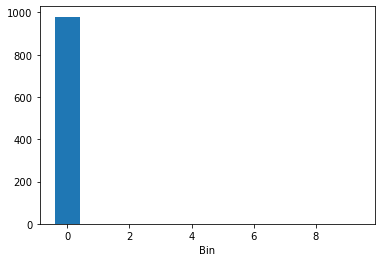

In [26]:
import matplotlib.pyplot as plt
#plt.plot(torch.histogram(temp[:, 3]), bins=10, range=(0., 1.))
#plt.hist(temp[:, 3], bins=10, range=(0,1))
if obj=='bbox':
    hist = torch.histc(temp[:, 4], bins = 10, min = 0, max = 1)
else:
    hist = torch.histc(temp[:, 3], bins = 10, min = 0, max = 1)

bins = 10
x = range(bins)
plt.bar(x, hist.to('cpu'), align='center')
plt.xlabel('Bin')

0
image range, max tensor(0.3415, device='cuda:0')
1
image range, max tensor(0.4248, device='cuda:0')
2
image range, max tensor(0.4032, device='cuda:0')
3
image range, max tensor(0.3723, device='cuda:0')
4
image range, max tensor(0.3616, device='cuda:0')
5
image range, max tensor(0.3465, device='cuda:0')
6
image range, max tensor(0.3161, device='cuda:0')
7
image range, max tensor(0.4065, device='cuda:0')


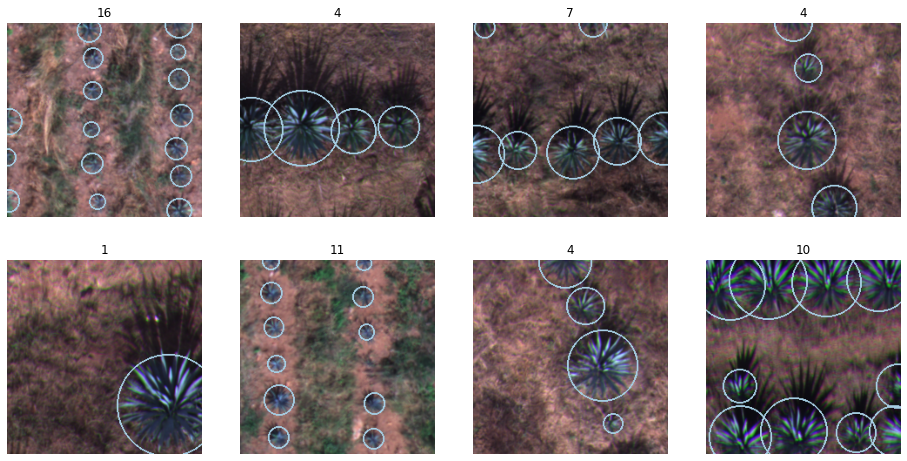

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont
import rasterio as rio

# bounding box colormap 설정
cmap = np.array(plt.cm.get_cmap('Paired').colors)
cmap_rgb: list = np.multiply(cmap, 255).astype(np.int32).tolist()
plt.figure(figsize=(16, 8))
# 결과 이미지를 저장하는 코드
#os.makedirs(args.save_folder, exist_ok=True)
for i, (path, img, predict) in enumerate(zip(img_paths, images, output) ):
    print(i)
    # 원본 이미지 열기
    #path = path.replace('\\', '/')
    #image = Image.open(path).convert('RGB')
    #with rio.open(path) as img :
    #    image = img.read()[0:3,:,:]
    image = 255*img[0:3,...]/img.max()
    #image = Image.fromarray((image.transpose(1, 2, 0))[:,:,[0,1,2]].astype('uint8'))
    image = Image.fromarray(np.array((image.permute(1, 2, 0))[:,:,[2,1,0]].cpu()).astype('uint8'))
    print("image range, max "+ str(img.max()))
    draw = ImageDraw.Draw(image)

    if predict is not None:
        # 원본 이미지로 bounding box를 rescale한다.
        #prediction = utils.utils.rescale_boxes_original(prediction, 224, image.size)

        #for x1, y1, r, obj_conf in predict:
        for box in predict:
            # bounding box color 설정
            color = tuple(cmap_rgb[int(0) % len(cmap_rgb)])

            if obj=='bbox':
                xc, yc, w, h, obj_conf, cls = box
                x1, y1, x2, y2 = xc-w/2, yc-h/2, xc+w/2, yc+h/2
                draw.rectangle(((x1, y1), (x2, y2)), outline=color, width=2)
            else:
                #xc, yc, r, obj_conf, cls = box
                xc, yc, r, obj_conf = box
                draw.ellipse((xc-r, yc-r, xc+r, yc+r), outline=color, width=2)

            # label 그리기
            #text = '{} {:.1f}'.format(" ", obj_conf.item() * 100)
            #text = '{} {:d}'.format(" ", int(cls.item()) )
            #font = ImageFont.truetype('calibri.ttf', size=12)
            #text_width, text_height = (10, 15)#font.getsize(text)
            #draw.rectangle(((xc, yc), (xc + text_width, yc + text_height)), fill=color)
            #draw.text((xc, yc), text, fill=(0, 0, 0), font=font)
    plt.subplot(2, 4, i+1)
    plt.imshow(image); plt.axis('off')
    plt.title(len(predict))
    if i+1==8:
        break

In [11]:
prediction[1][0][1].shape

torch.Size([224, 224])

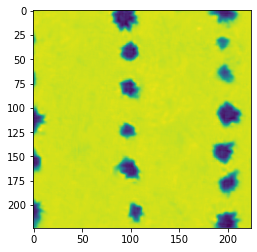

In [14]:
plt.imshow(prediction[1][0][0].cpu())